# M4 – Exploratory Data Analysis Report

## Investigating the Relationship Between Classroom Environmental Conditions and Student Performance

### Group 6

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import ttest_ind

# ==========================================
# Environment Setup and Unified Color Palette
# ==========================================
sns.set_theme(style="ticks")
sns.set_style("whitegrid")

PALETTE_MAIN_BLUE = "#7C9895"
PALETTE_ACCENT = "#E37222"
main_color = "#92A5D1"
second_color = "#7C9895"
third_color = "#DAA87C"
light_color = "#C9DCC4"

plt.rcParams["font.sans-serif"] = ["Arial", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

def format_y_label(ax, x=-0.16):
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_horizontalalignment("right")
    ax.yaxis.label.set_verticalalignment("center")
    ax.yaxis.set_label_coords(x, 0.5)

df = pd.read_csv("final_dataset_after_cleaned.csv")

# 1. Dataset Overview

This section introduces the dataset structure, variable composition, and data quality characteristics before conducting exploratory analyses.

In [2]:
df.shape
df.info()
df.isnull().sum().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            2000 non-null   object 
 1   day                   2000 non-null   object 
 2   period                2000 non-null   object 
 3   subject               2000 non-null   object 
 4   grade                 2000 non-null   object 
 5   age                   2000 non-null   float64
 6   has_asthma            2000 non-null   int64  
 7   co2_ppm               2000 non-null   float64
 8   pm25_ugm3             2000 non-null   float64
 9   temperature_c         2000 non-null   float64
 10  humidity_pct          2000 non-null   float64
 11  air_quality_label     2000 non-null   object 
 12  quiz_score            2000 non-null   float64
 13  reaction_time_ms      2000 non-null   int64  
 14  focus_rating          2000 non-null   float64
 15  error_rate           

np.int64(0)

The dataset contains no missing values and no duplicate observations. Therefore, no imputation or record removal was required prior to analysis.

# 2. Univariate Analysis

Univariate analysis examines the distribution and characteristics of individual variables. The objective is to understand central tendency, variability, and potential outliers before investigating relationships between variables.

## Figure 1. Distribution of Quiz Scores


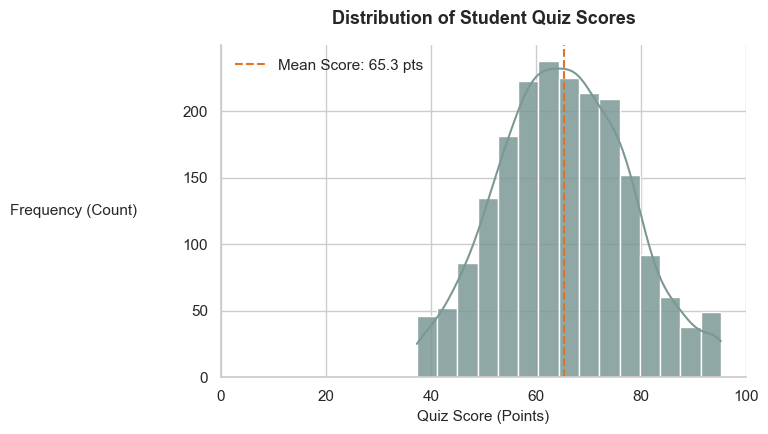

In [68]:
# ==========================================
# Figure 1: Distribution of Student Quiz Scores
# Principle: Single-color design, highlight mean value, self-explanatory presentation
# ==========================================
plt.figure(figsize=(8, 4.5))

sns.histplot(
    data=df,
    x="quiz_score",
    kde=True,
    color=PALETTE_MAIN_BLUE,
    bins=15,
    alpha=0.85,
)

mean_score = df["quiz_score"].mean()
plt.axvline(
    mean_score,
    color=PALETTE_ACCENT,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean Score: {mean_score:.1f} pts",
)

plt.title("Distribution of Student Quiz Scores", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Quiz Score (Points)", fontsize=11)
plt.ylabel("Frequency (Count)", fontsize=11)
format_y_label(plt.gca())

plt.xlim(0, 100)
plt.legend(frameon=False, loc="upper left")
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

## Distribution of Quiz Scores

The histogram shows that quiz scores are approximately bell-shaped, with most students achieving scores between 50 and 80. The average score is indicated by the vertical dashed line and lies close to the center of the distribution.

Interpretation:
The relatively balanced distribution suggests that the target variable is suitable for predictive modelling. There is no strong evidence of severe class imbalance or extreme skewness that would require major transformation.

## Figure 2. Distribution of Classroom CO₂ Concentration


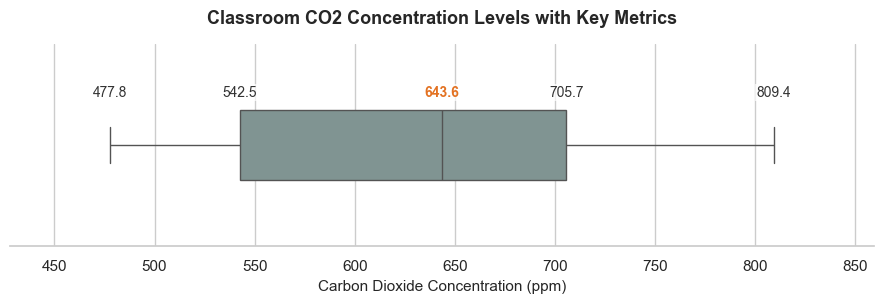

In [67]:
# ==========================================
# Figure 2: Distribution of Classroom CO2 Concentration
# Principle: Direct annotation of five-number summary, minimalist design, high data-ink ratio
# ==========================================
plt.figure(figsize=(9, 3.2))

co2_data = df["co2_ppm"].dropna()
q1 = np.percentile(co2_data, 25)
median = np.percentile(co2_data, 50)
q3 = np.percentile(co2_data, 75)
iqr = q3 - q1

lower_whisker = co2_data[co2_data >= (q1 - 1.5 * iqr)].min()
upper_whisker = co2_data[co2_data <= (q3 + 1.5 * iqr)].max()

sns.boxplot(
    data=df,
    x="co2_ppm",
    color=PALETTE_MAIN_BLUE,
    width=0.35,
    fliersize=4,
    flierprops={
        "marker": "o",
        "markerfacecolor": "none",
        "markeredgecolor": "gray",
        "alpha": 0.5,
    },
)

five_numbers = {
    "Min": lower_whisker,
    "Q1": q1,
    "Median": median,
    "Q3": q3,
    "Max": upper_whisker,
}

for label, val in five_numbers.items():
    is_median = label == "Median"
    font_color = PALETTE_ACCENT if is_median else "#333333"
    font_weight = "bold" if is_median else "normal"

    plt.text(
        x=val,
        y=-0.26,
        s=f"{val:.1f}",
        ha="center",
        va="center",
        color=font_color,
        fontsize=10,
        fontweight=font_weight,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1),
    )

plt.title("Classroom CO2 Concentration Levels with Key Metrics", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Carbon Dioxide Concentration (ppm)", fontsize=11)

sns.despine(top=True, right=True, left=True)
plt.yticks([])
plt.xlim(df["co2_ppm"].min() - 50, df["co2_ppm"].max() + 50)

plt.tight_layout()
plt.show()

## Distribution of Classroom CO₂ Concentration

The boxplot reveals substantial variation in classroom CO₂ concentrations. Several observations appear above the upper whisker, indicating potential high-CO₂ events.

Interpretation:
The presence of elevated CO₂ levels suggests that ventilation quality differs considerably across observations. These high-CO₂ conditions may influence cognitive performance and should be retained for further analysis rather than automatically removed as outliers.

## Figure 3. Distribution of Air Quality Categories


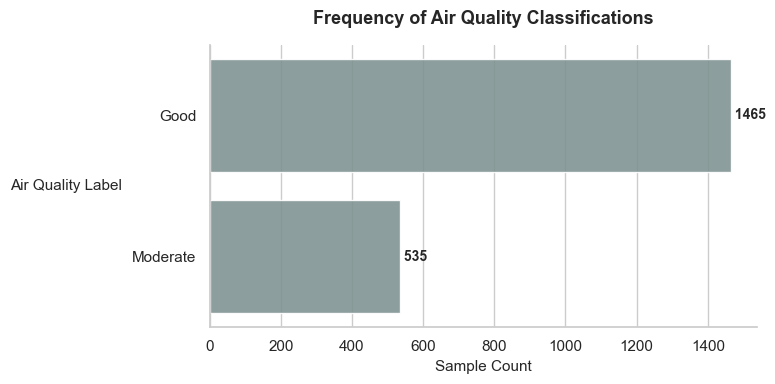

In [66]:
# ==========================================
# Figure 3: Distribution of Air Quality Categories
# Principle: Horizontal bar chart, direct value labels, frequency-based ordering
# ==========================================
plt.figure(figsize=(8, 4))

order = df["air_quality_label"].value_counts().index

ax = sns.countplot(
    data=df,
    y="air_quality_label",
    order=order,
    color=PALETTE_MAIN_BLUE,
    alpha=0.9
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f" {int(width)}",
        (width, p.get_y() + p.get_height() / 2.0),
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
    )

plt.title("Frequency of Air Quality Classifications", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Sample Count", fontsize=11)
plt.ylabel("Air Quality Label", fontsize=11)
format_y_label(plt.gca())

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

## Distribution of Air Quality Categories

The count plot shows that observations are not evenly distributed across air-quality categories. Good air-quality conditions account for the largest proportion of observations.

Interpretation:
The imbalance in category frequencies should be considered during later modelling because dominant categories may exert a stronger influence on model fitting.

## Figure 4. Distribution of Student Performance Categories


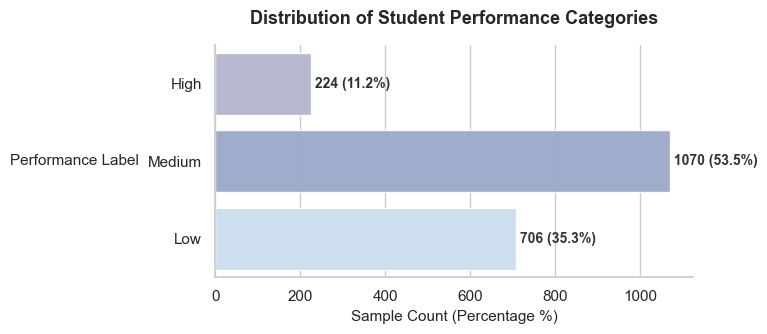

In [65]:
# ==========================================
# Figure 4: Distribution of Student Performance Categories
# Principle: Avoid pie charts, logical ordering, self-explanatory and visually clean design
# ==========================================
plt.figure(figsize=(8, 3.5))

perf_order = ["High", "Medium", "Low"]
custom_palette = {"High": "#AEB2D1", "Medium": "#92A5D1", "Low": "#C5DFF4"}

ax2 = sns.countplot(
    data=df,
    y="performance_label",
    order=perf_order,
    hue="performance_label",
    palette=custom_palette,
    legend=False,
    alpha=0.95,
)

total_samples = len(df)

for p in ax2.patches:
    width = p.get_width()
    if width == 0 or np.isnan(width):
        continue

    percentage = (width / total_samples) * 100
    ax2.annotate(
        f" {int(width)} ({percentage:.1f}%)",
        (width, p.get_y() + p.get_height() / 2.0),
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="#333333",
    )

plt.title("Distribution of Student Performance Categories", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Sample Count (Percentage %)", fontsize=11)
plt.ylabel("Performance Label", fontsize=11)
format_y_label(plt.gca())

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

## Distribution of Student Performance Categories

Student performance categories are distributed across multiple levels, with moderate and high-performance groups representing the majority of observations.

Interpretation:
The distribution indicates that student performance varies substantially across the dataset, providing sufficient variability for predictive analysis.

# 3. Bivariate Analysis

Bivariate analysis explores relationships between pairs of variables and evaluates whether environmental conditions are associated with student performance outcomes.

## Figure 5. Relationship Between CO₂ Concentration and Quiz Score

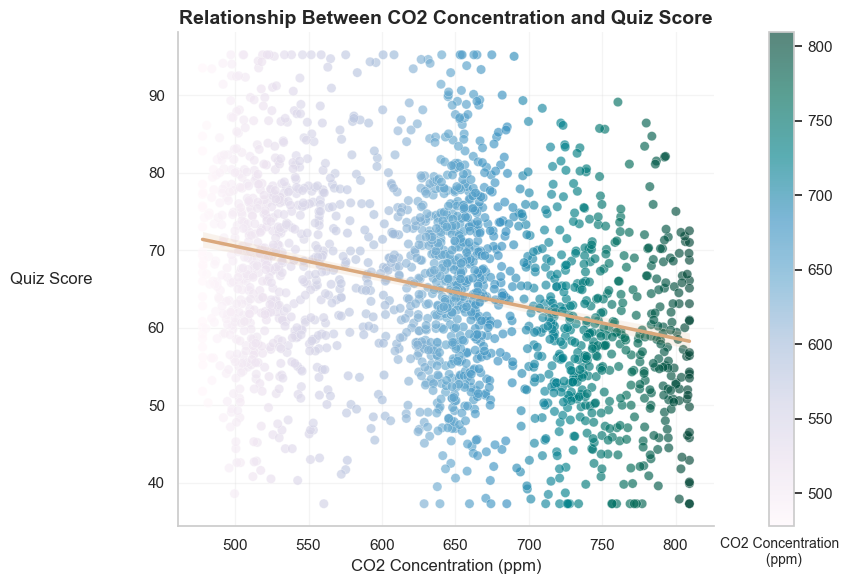

In [64]:
# ==========================================
# Figure 5: Relationship Between CO2 Concentration and Quiz Score
# Principle: Scatter plot for relationship visualization, regression line for trend interpretation, color encoding for concentration levels
# ==========================================
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df["co2_ppm"],
    df["quiz_score"],
    c=df["co2_ppm"],
    cmap="PuBuGn",
    alpha=0.65,
    s=45,
    edgecolors="white",
    linewidths=0.3
)

sns.regplot(
    data=df,
    x="co2_ppm",
    y="quiz_score",
    scatter=False,
    line_kws={
        "color": "#DAA87C",
        "linewidth": 2.5
    }
)

cbar = plt.colorbar(scatter, pad=0.08)
cbar.ax.set_xlabel("CO2 Concentration \n (ppm)", fontsize=10, labelpad=8)
cbar.ax.xaxis.set_label_position("bottom")

plt.title("Relationship Between CO2 Concentration and Quiz Score", fontsize=14, fontweight="bold")
plt.xlabel("CO2 Concentration (ppm)", fontsize=12)
plt.ylabel("Quiz Score", fontsize=12)
format_y_label(plt.gca())

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [8]:
corr, p = pearsonr(
    df['co2_ppm'],
    df['quiz_score']
)

print("Correlation:",corr)
print("P-value:",p)

Correlation: -0.2959069125897208
P-value: 1.0516758759028431e-41


### Interpretation

A statistically significant negative relationship was observed between classroom CO₂ concentration and quiz score (r = -0.296, p < 0.001).

Although the effect size is moderate, the relationship is highly significant due to the large sample size. Students exposed to higher CO₂ concentrations generally achieved lower quiz scores.

This finding supports the hypothesis that poorer classroom ventilation may be associated with reduced academic performance.

## Figure 6. Relationship Between CO₂ Concentration and Reaction Time

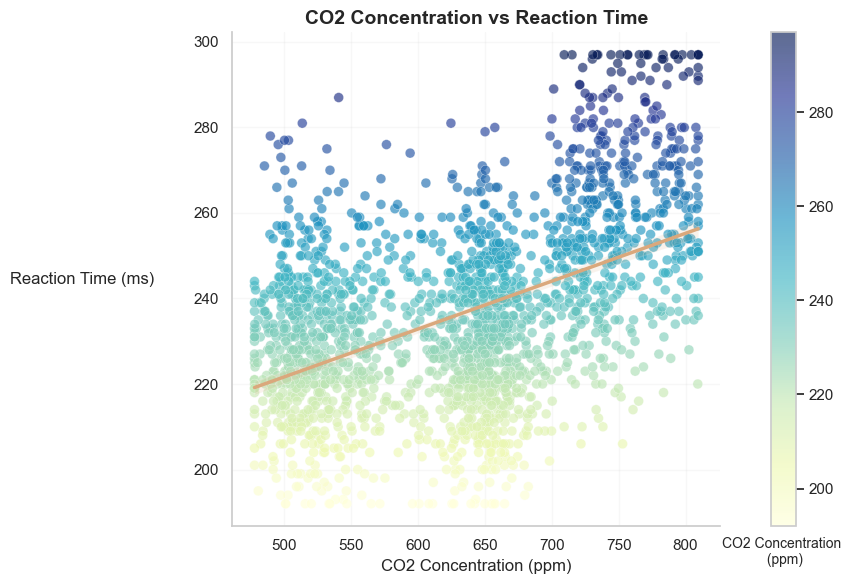

In [63]:
# ==========================================
# Figure 6: Relationship Between CO2 Concentration and Reaction Time
# Principle: Scatter plot for trend visualization, regression line for direction indication, color bar for additional information
# ==========================================
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df["co2_ppm"],
    df["reaction_time_ms"],
    c=df["reaction_time_ms"],
    cmap="YlGnBu",
    alpha=0.65,
    s=50,
    edgecolors="white",
    linewidths=0.3
)

sns.regplot(
    data=df,
    x="co2_ppm",
    y="reaction_time_ms",
    scatter=False,
    line_kws={
        "color": "#DAA87C",
        "linewidth": 2.5
    }
)

cbar = plt.colorbar(scatter, pad=0.08)
cbar.ax.set_xlabel("CO2 Concentration \n (ppm)", fontsize=10, labelpad=8)
cbar.ax.xaxis.set_label_position("bottom")

plt.title("CO2 Concentration vs Reaction Time", fontsize=14, fontweight="bold")
plt.xlabel("CO2 Concentration (ppm)", fontsize=12)
plt.ylabel("Reaction Time (ms)", fontsize=12)
format_y_label(plt.gca())

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)

plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

In [10]:
corr, p = pearsonr(
    df['co2_ppm'],
    df['reaction_time_ms']
)

print("Correlation:",corr)
print("P-value:",p)

Correlation: 0.4709677145162288
P-value: 5.916576187804405e-111


## Relationship Between CO₂ Concentration and Reaction Time

### Results

Pearson correlation analysis produced:

- Correlation coefficient (r) = **0.471**
- p-value < **0.001**

### Interpretation

A moderate positive relationship exists between CO₂ concentration and reaction time.

As classroom CO₂ levels increase, students require more time to respond to cognitive tasks. Since longer reaction times indicate slower cognitive processing speed, elevated CO₂ concentrations appear to impair cognitive efficiency.

Compared with Figure 1, this relationship is stronger, suggesting that air quality may affect cognitive functioning more directly than academic scores.

### Key Takeaway

> Higher CO₂ concentrations are associated with slower reaction times and reduced cognitive responsiveness.

## Figure 7. Quiz Score Across Air Quality Categories

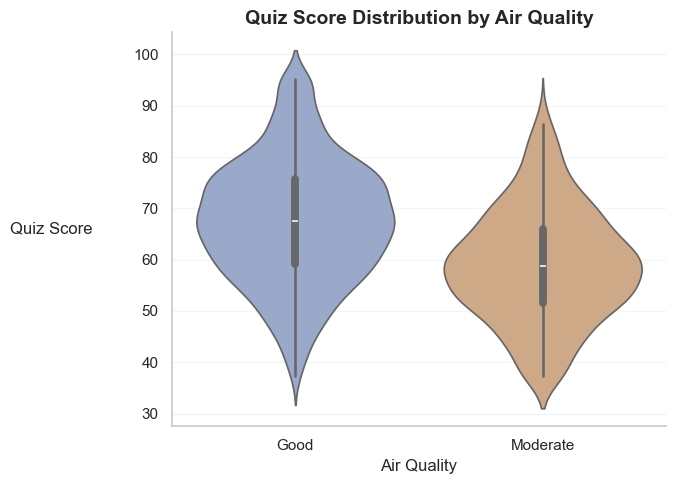

In [62]:
# ==========================================
# Figure 7: Quiz Score Distribution Across Air Quality Categories
# Principle: Show group differences, preserve distribution information, reduce visual clutter
# ==========================================
plt.figure(figsize=(7, 5))

sns.violinplot(
    data=df,
    x="air_quality_label",
    y="quiz_score",
    hue="air_quality_label",
    inner="box",
    palette=["#92A5D1", "#DAA87C"],
    legend=False
)

plt.title("Quiz Score Distribution by Air Quality", fontsize=14, fontweight="bold")
plt.xlabel("Air Quality")
plt.ylabel("Quiz Score")
format_y_label(plt.gca())

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [12]:
df.groupby('air_quality_label')['quiz_score'].describe()

,count,mean,std,min,25%,50%,75%,max
air_quality_label,,,,,,,,
Good,1465.0,67.526849,12.037983,37.299,59.1,67.5,75.7,95.202
Moderate,535.0,59.023712,10.991883,37.299,51.6,58.8,66.0,89.100


In [13]:
groups = []

for g in df['air_quality_label'].unique():
    groups.append(
        df[df['air_quality_label']==g]['quiz_score']
    )

for i in range(len(groups)-1):

    stat,p = ttest_ind(
        groups[i],
        groups[i+1]
    )

    print(stat,p)

14.304593277043763 2.9071230340153964e-44


## Quiz Score Across Air Quality Categories

### Descriptive Statistics

| Air Quality | Mean Quiz Score |
|------------|----------------|
| Good | 67.53 |
| Moderate | 59.02 |

Difference:

```text
67.53 - 59.02 = 8.51 points
```

### Statistical Test

Independent t-test results:

- t = 14.30
- p < 0.001

### Interpretation

Students studying in classrooms classified as having Good air quality achieved substantially higher quiz scores than those in Moderate air quality environments.

The average score difference exceeds 8 points, which is educationally meaningful. The t-test confirms that this difference is statistically significant.

The boxplot also shows that the median score and upper quartile are consistently higher in the Good air quality group.

### Key Takeaway

> Better classroom air quality is associated with significantly improved academic performance.


# 4. Multivariate Analysis

Multivariate analysis investigates how multiple variables interact simultaneously and identifies broader patterns that may not be visible through pairwise analysis alone.

## Figure 8. Correlation Heatmap of Numerical Variables

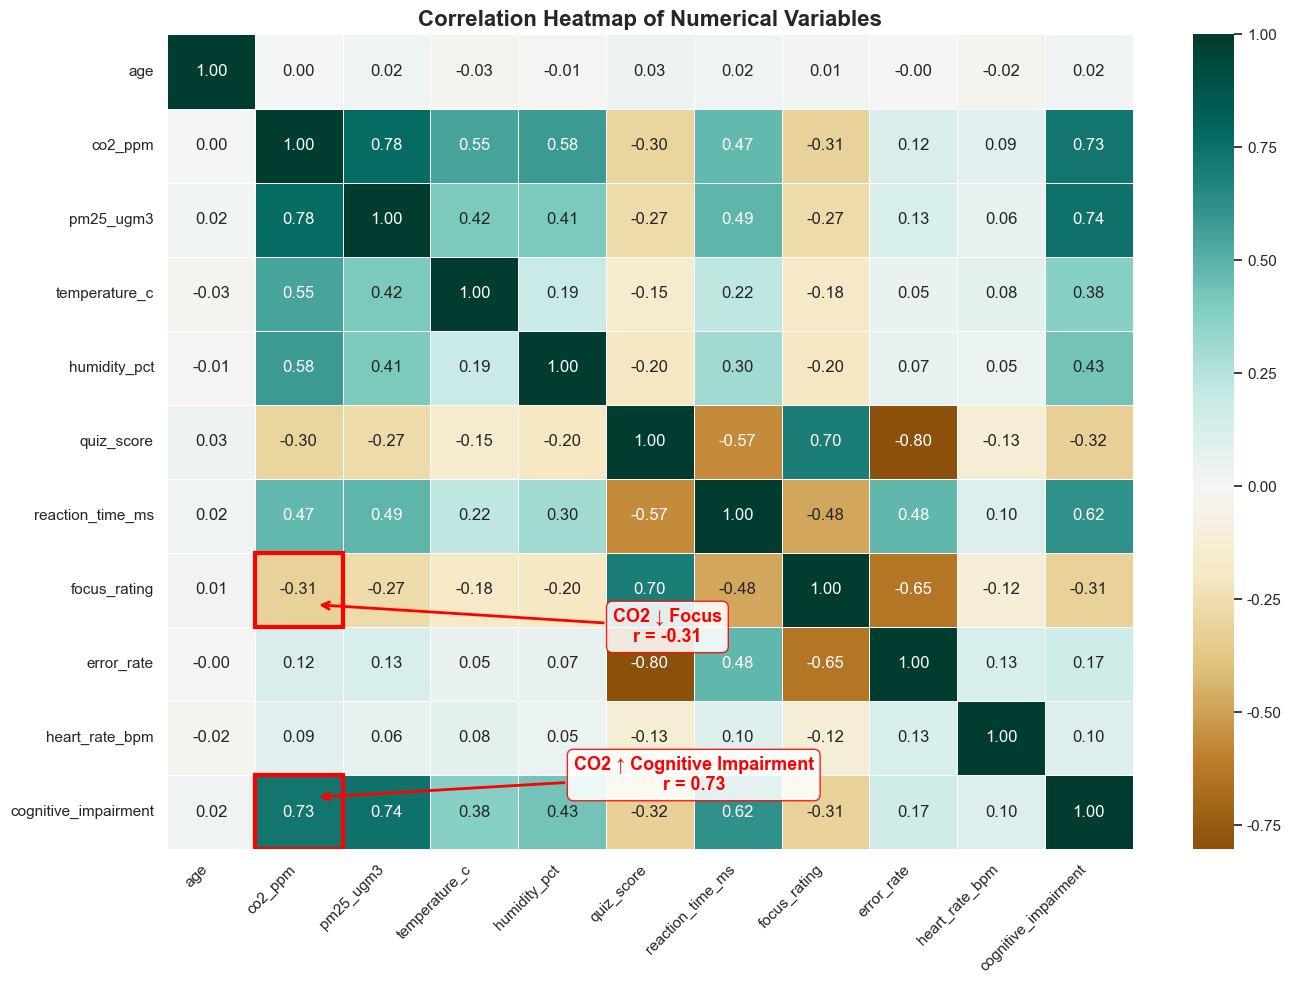

In [88]:
# ==========================================
# Figure 8: Correlation Heatmap of Numerical Variables
# Principle: Highlight key relationships, retain correlation coefficients, self-explanatory visualization
# ==========================================
from matplotlib.patches import Rectangle

numeric_cols = [
    "age",
    "co2_ppm",
    "pm25_ugm3",
    "temperature_c",
    "humidity_pct",
    "quiz_score",
    "reaction_time_ms",
    "focus_rating",
    "error_rate",
    "heart_rate_bpm",
    "cognitive_impairment"
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="BrBG",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
)

focus_row = numeric_cols.index("focus_rating")
co2_col = numeric_cols.index("co2_ppm")
cog_row = numeric_cols.index("cognitive_impairment")

ax.add_patch(
    Rectangle(
        (co2_col, focus_row),
        1,
        1,
        fill=False,
        edgecolor="red",
        lw=3
    )
)

ax.add_patch(
    Rectangle(
        (co2_col, cog_row),
        1,
        1,
        fill=False,
        edgecolor="red",
        lw=3
    )
)

ax.annotate(
    "CO2 ↓ Focus\nr = -0.31",
    xy=(co2_col + 0.7, focus_row + 0.7),
    xytext=(5.7, 8.0),
    fontsize=13,
    fontweight="bold",
    color="red",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=2
    ),
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc="white",
        ec="red",
        alpha=0.88
    )
)

ax.annotate(
    "CO2 ↑ Cognitive Impairment\nr = 0.73",
    xy=(co2_col + 0.7, cog_row + 0.3),
    xytext=(6.0, 10.0),
    fontsize=13,
    fontweight="bold",
    color="red",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=2
    ),
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc="white",
        ec="red",
        alpha=0.88
    )
)

plt.title("Correlation Heatmap of Numerical Variables", fontsize=16, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Correlation Heatmap

### Major Findings

### 1. Academic Performance Relationships

The heatmap reveals several strong relationships between quiz performance and cognitive indicators.

| Variable | Correlation with Quiz Score |
|-----------|------------|
| Focus Rating | +0.70 |
| Reaction Time | -0.57 |
| Error Rate | -0.80 |
| Cognitive Impairment | -0.32 |

Students with higher focus ratings generally achieve better quiz scores. In contrast, longer reaction times, higher error rates, and greater cognitive impairment are associated with lower academic performance.

The strongest relationship is observed between **Error Rate** and **Quiz Score** (*r = -0.80*), indicating that students who make more mistakes tend to perform substantially worse on quizzes.

### 2. Environmental Factors

The heatmap also shows that classroom environmental conditions are related to both cognitive and academic outcomes.

| Variable | Correlation with CO₂ Concentration |
|-----------|------------|
| Quiz Score | -0.30 |
| Reaction Time | +0.47 |
| Focus Rating | -0.31 |
| Cognitive Impairment | +0.73 |

These results suggest that higher CO₂ concentrations are associated with:

- Lower quiz scores
- Reduced student focus
- Slower reaction times
- Higher cognitive impairment

Among these relationships, the strongest is between **CO₂ concentration** and **Cognitive Impairment** (*r = 0.73*), indicating that poor ventilation may have a substantial impact on cognitive functioning.


### 3. Pollution Indicators

PM2.5 concentration exhibits similar patterns to CO₂ concentration.

| Variable | Correlation with PM2.5 |
|-----------|------------|
| Quiz Score | -0.27 |
| Reaction Time | +0.49 |
| Cognitive Impairment | +0.74 |

The findings indicate that increased particulate pollution is associated with:

- Lower academic achievement
- Slower cognitive responses
- Greater cognitive impairment

The strong positive correlation between **PM2.5** and **Cognitive Impairment** (*r = 0.74*) further supports the hypothesis that air pollution may negatively affect students' cognitive performance.


### Interpretation

Overall, the heatmap suggests that classroom environmental quality is closely associated with both cognitive functioning and academic performance. Students exposed to poorer air quality tend to demonstrate reduced concentration, slower reaction speeds, greater cognitive impairment, and lower quiz scores.

Additionally, cognitive indicators such as focus rating and error rate appear to have the strongest direct relationships with academic performance, suggesting that cognitive functioning may act as an important pathway through which environmental conditions influence learning outcomes.
Strong correlations among environmental variables indicate that multicollinearity should be assessed before building predictive models.

### Key Takeaway

> Environmental quality variables exhibit meaningful relationships with cognitive and academic performance indicators. The results support the inclusion of environmental, physiological, and cognitive variables in subsequent predictive modelling tasks.

## Figure 9. Interaction Between Air Quality and Asthma Status

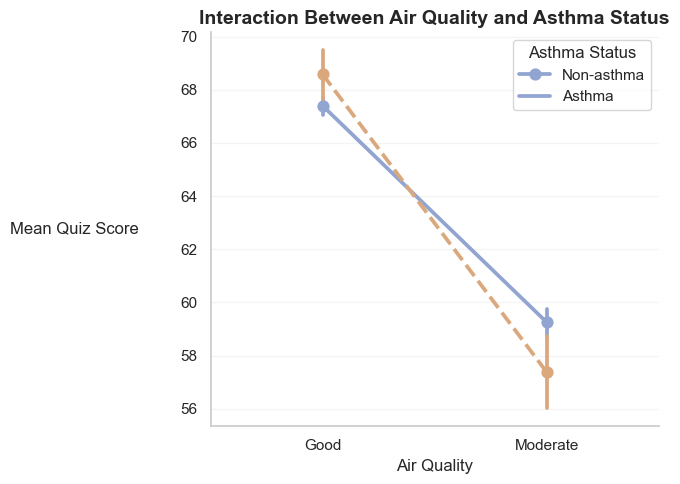

In [58]:
# ==========================================
# Figure 9: Interaction Between Air Quality and Asthma Status
# Principle: Display mean trends, distinguish group patterns, preserve uncertainty information
# ==========================================
plt.figure(figsize=(7, 5))

sns.pointplot(
    data=df,
    x="air_quality_label",
    y="quiz_score",
    hue="has_asthma",
    errorbar="se",
    markers=["o", "o"],
    linestyles=["-", "--"],
    palette=["#92A5D1", "#DAA87C"]
)

plt.title("Interaction Between Air Quality and Asthma Status", fontsize=14, fontweight="bold")
plt.xlabel("Air Quality")
plt.ylabel("Mean Quiz Score")
format_y_label(plt.gca())

plt.legend(title="Asthma Status", labels=["Non-asthma", "Asthma"])

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [16]:
df.groupby(
    ['air_quality_label','has_asthma']
)['quiz_score'].mean()

air_quality_label  has_asthma
Good               0             67.396952
                   1             68.578932
Moderate           0             59.244886
                   1             57.366667
Name: quiz_score, dtype: float64

## Interaction Between Air Quality and Asthma Status

### Group Means

| Air Quality | Asthma | Mean Score |
|------------|---------|------------|
| Good | No | 67.40 |
| Good | Yes | 68.58 |
| Moderate | No | 59.24 |
| Moderate | Yes | 57.37 |

### Interpretation

The impact of air quality appears stronger among students with asthma.

For students without asthma:

```text
67.40 → 59.24
Decrease = 8.16 points
```

For students with asthma:

```text
68.58 → 57.37
Decrease = 11.21 points
```

The performance decline associated with poorer air quality is approximately 3 points larger among students with asthma.

This suggests that asthma may increase vulnerability to environmental conditions and amplify the negative effects of reduced air quality.

The effect of air quality appears to differ slightly between students with and without asthma, suggesting the possibility of interaction effects. This relationship will be explored further during modelling.

### Key Takeaway

> Students with asthma appear more sensitive to deteriorating classroom air quality than students without asthma.


## Figure 10. Pairplot of Key Variables

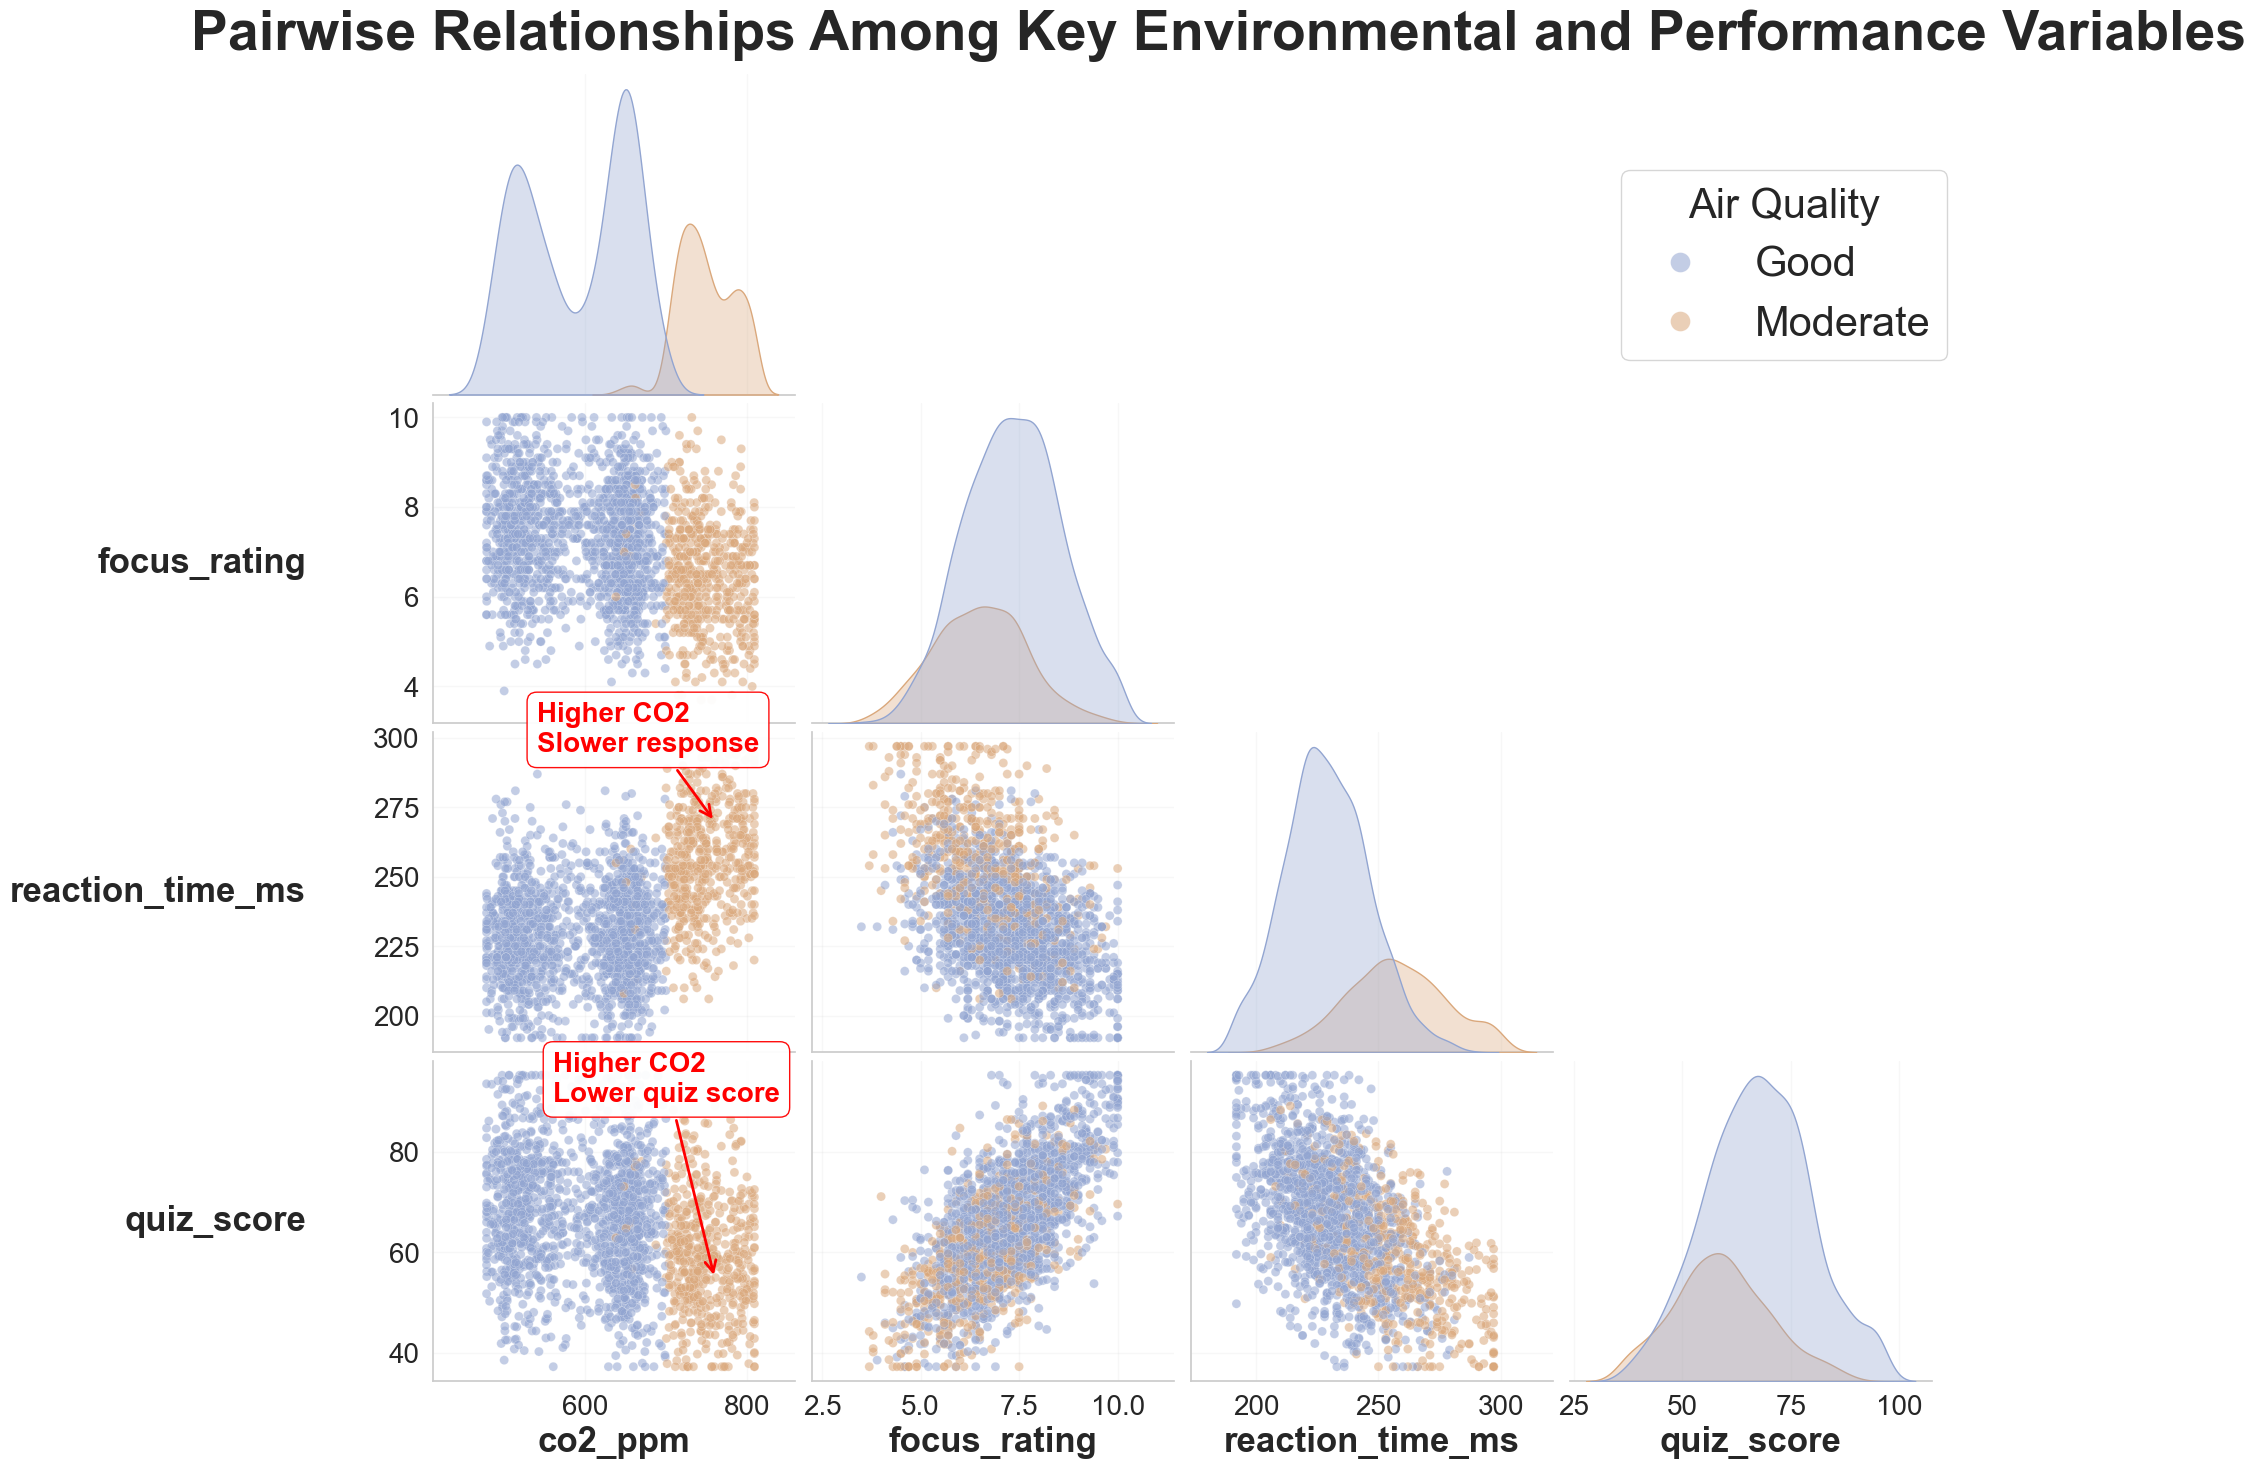

In [59]:
# ==========================================
# Figure 10: Pairwise Relationships Among Key Environmental and Performance Variables
# Principle: Centralized relationship exploration, consistent labeling, emphasis on important patterns
# ==========================================
selected_cols = [
    "co2_ppm",
    "focus_rating",
    "reaction_time_ms",
    "quiz_score",
    "air_quality_label"
]

g = sns.pairplot(
    df[selected_cols],
    vars=[
        "co2_ppm",
        "focus_rating",
        "reaction_time_ms",
        "quiz_score"
    ],
    hue="air_quality_label",
    corner=True,
    diag_kind="kde",
    height=3.5,
    aspect=1.15,
    palette=["#92A5D1", "#DAA87C"],
    plot_kws={
        "alpha": 0.55,
        "s": 42,
        "edgecolor": "white",
        "linewidth": 0.25
    },
    diag_kws={
        "fill": True,
        "alpha": 0.35
    }
)

g.fig.suptitle(
    "Pairwise Relationships Among Key Environmental and Performance Variables",
    fontsize=40,
    fontweight="bold",
    y=1.03
)

for ax in g.axes.flatten():
    if ax is not None:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(alpha=0.15)

        ax.tick_params(axis="both", labelsize=20)

        ax.xaxis.label.set_size(25)
        ax.xaxis.label.set_fontweight("bold")

        ax.yaxis.label.set_size(25)
        ax.yaxis.label.set_fontweight("bold")
        ax.yaxis.label.set_rotation(0)
        ax.yaxis.label.set_horizontalalignment("right")
        ax.yaxis.label.set_verticalalignment("center")
        ax.yaxis.set_label_coords(-0.35, 0.5)

        for label in ax.get_xticklabels():
            label.set_rotation(0)

        for label in ax.get_yticklabels():
            label.set_rotation(0)

if g._legend is not None:
    g._legend.remove()

handles, labels = g.axes[1, 0].get_legend_handles_labels()

g.fig.legend(
    handles,
    labels,
    title="Air Quality",
    loc="upper right",
    bbox_to_anchor=(0.93, 0.93),
    frameon=True,
    fontsize=30,
    title_fontsize=30,
    markerscale=2.2
)

ax1 = g.axes[3, 0]
ax1.annotate(
    "Higher CO2\nLower quiz score",
    xy=(760, 55),
    xytext=(560, 90),
    fontsize=20,
    fontweight="bold",
    color="red",
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=2
    ),
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc="white",
        ec="red",
        alpha=0.95
    )
)

ax2 = g.axes[2, 0]
ax2.annotate(
    "Higher CO2\nSlower response",
    xy=(760, 270),
    xytext=(540, 295),
    fontsize=20,
    fontweight="bold",
    color="red",
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=2
    ),
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc="white",
        ec="red",
        alpha=0.95
    )
)

plt.show()

## Multivariate Relationships Among Environmental and Learning Variables

### Interpretation

The pairplot provides a comprehensive view of interactions among environmental conditions, cognitive measures, and academic performance.

Several consistent patterns emerge:

1. Higher CO₂ and PM2.5 levels tend to be associated with lower quiz scores.
2. Students with higher focus ratings generally achieve better academic performance.
3. Longer reaction times are linked to poorer quiz outcomes.
4. Environmental pollutants appear to influence learning indirectly through cognitive mechanisms such as attention and reaction speed.

These patterns suggest a potential pathway:

```text
Poor Air Quality
       ↓
Reduced Cognitive Function
       ↓
Lower Academic Performance
```

### Key Takeaway

> Environmental factors may influence academic achievement both directly and indirectly through their effects on cognition and attention.

## Figure 11. Interaction Features and Quiz Score

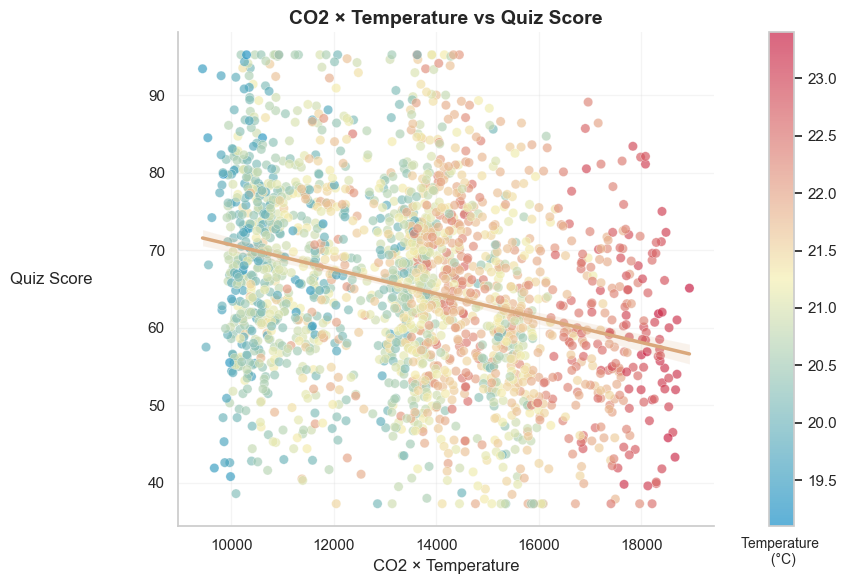

In [60]:
# ==========================================
# Figure 11: Effect of CO2–Temperature Interaction on Quiz Score
# Principle: Visualize interaction effects, color encoding for temperature, regression line for trend interpretation
# ==========================================
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "temp_cmap",
    ["#0787C3", "#F4EEAC", "#C6133B"]
)

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df["co2_x_temperature"],
    df["quiz_score"],
    c=df["temperature_c"],
    cmap=custom_cmap,
    alpha=0.65,
    s=45,
    edgecolors="white",
    linewidths=0.3
)

sns.regplot(
    data=df,
    x="co2_x_temperature",
    y="quiz_score",
    scatter=False,
    line_kws={
        "color": "#DAA87C",
        "linewidth": 2.5
    }
)

cbar = plt.colorbar(scatter, pad=0.08)
cbar.ax.set_xlabel("Temperature \n (°C)", fontsize=10, labelpad=8)
cbar.ax.xaxis.set_label_position("bottom")

plt.title("CO2 × Temperature vs Quiz Score", fontsize=14, fontweight="bold")
plt.xlabel("CO2 × Temperature")
plt.ylabel("Quiz Score")
format_y_label(plt.gca())

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [19]:
from scipy.stats import pearsonr

r_temp, p_temp = pearsonr(df["co2_x_temperature"], df["quiz_score"])
r_hum, p_hum = pearsonr(df["co2_x_humidity"], df["quiz_score"])

print("CO2 x Temperature vs Quiz Score:")
print(f"r = {r_temp:.3f}, p = {p_temp:.3e}")

print("CO2 x Humidity vs Quiz Score:")
print(f"r = {r_hum:.3f}, p = {p_hum:.3e}")

CO2 x Temperature vs Quiz Score:
r = -0.289, p = 1.029e-39
CO2 x Humidity vs Quiz Score:
r = -0.296, p = 8.464e-42


# 5. Revised Hypotheses

## H1: Higher classroom CO₂ concentrations are associated with lower quiz scores

**Supported by:**

- Pearson correlation coefficient: **r = -0.296**
- Statistical significance: **p < 0.001**

**Interpretation:**

EDA results indicate a statistically significant negative relationship between classroom CO₂ concentration and quiz performance. Students exposed to higher CO₂ levels tend to achieve lower quiz scores, suggesting that classroom ventilation conditions may be associated with academic performance.

---

## H2: Including classroom environmental variables may improve the prediction of student performance

**Supported by:**

- CO₂ concentration is significantly associated with quiz score (**r = -0.296, p < 0.001**)
- CO₂ concentration is significantly associated with reaction time (**r = 0.471, p < 0.001**)

**Interpretation:**

Environmental variables demonstrate meaningful relationships with multiple performance-related outcomes. These findings suggest that classroom environmental measurements may provide useful predictive information and improve model performance compared with using demographic or behavioural variables alone.

---

## H3: The relationship between classroom air quality and student performance may depend on interactions among environmental and health-related factors

**Supported by:**

- CO₂ vs Focus Rating: **r = -0.31**
- CO₂ vs Cognitive Impairment: **r = 0.73**
- Air Quality × Asthma interaction analysis

**Interpretation:**

The heatmap and interaction analyses suggest that environmental variables may not operate independently. Instead, the effect of classroom air quality on student performance may vary according to other factors such as asthma status. Additional modelling should evaluate interaction terms (e.g., CO₂ × Temperature, CO₂ × Humidity, and Air Quality × Asthma).

These interaction effects cannot be fully evaluated through correlation analysis alone and should be formally tested during the modelling stage.

---

## H4: Students with asthma may experience a greater decline in academic performance under poorer air quality conditions

**Supported by interaction analysis:**

| Group | Score Decline |
|---------|---------|
| Asthma | 11.21 points |
| Non-asthma | 8.16 points |

**Interpretation:**

Students with asthma exhibited a larger reduction in quiz performance as air quality deteriorated. This finding suggests that health status may moderate the relationship between classroom environmental conditions and academic outcomes.

# 6. Modelling Question

Can student quiz performance be accurately predicted using classroom environmental conditions, cognitive indicators, and demographic characteristics?

A secondary objective is to evaluate whether interaction effects among air quality, health status, and environmental variables improve predictive performance.

# 7. Conclusion

The EDA revealed significant relationships between classroom environmental conditions and student academic outcomes. Higher CO₂ concentrations were associated with lower quiz scores, slower reaction times, reduced focus, and greater cognitive impairment.

Interaction analysis further suggested that health-related characteristics, particularly asthma status, may modify the effect of environmental conditions on academic performance.

These findings support the inclusion of environmental and cognitive variables in subsequent predictive modelling and provide evidence for investigating interaction effects during model development.